In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("archive/Personal_Finance_Dataset.csv")

In [4]:
df.shape

(1500, 5)

In [5]:
df.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   object 
 1   Transaction Description  1500 non-null   object 
 2   Category                 1500 non-null   object 
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   object 
dtypes: float64(1), object(4)
memory usage: 58.7+ KB


## 1. Categorical Data

<Axes: xlabel='count', ylabel='Category'>

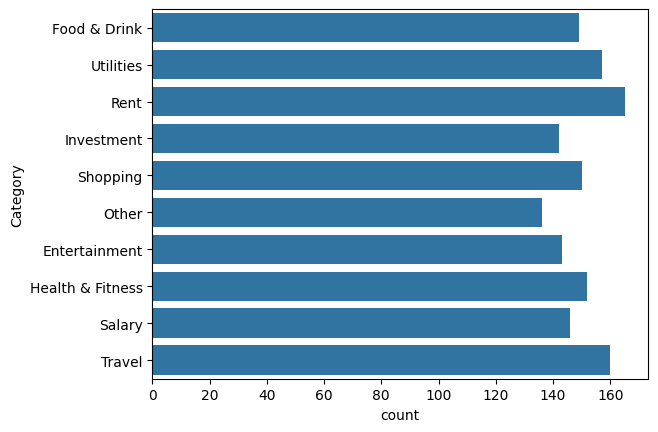

In [7]:
# sns.countplot(x = df['Category'])
# plt.xticks(rotation=30)

sns.countplot(df['Category'])

<Axes: ylabel='count'>

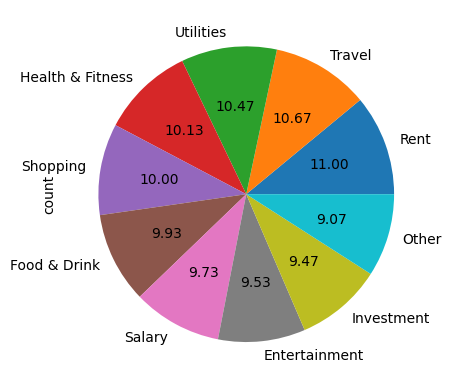

In [8]:
(df['Category']).value_counts().plot(kind='pie', autopct='%.2f')

<Axes: xlabel='count', ylabel='Type'>

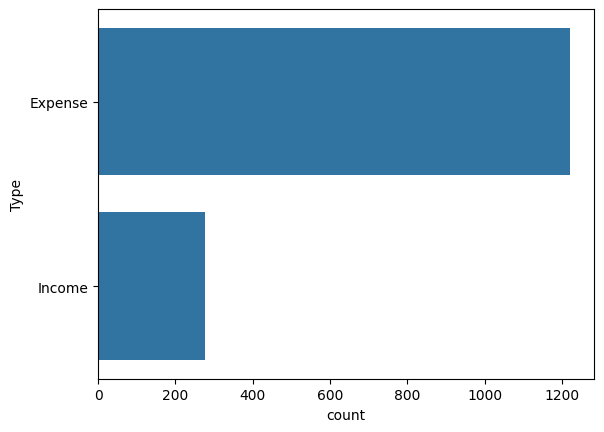

In [9]:
sns.countplot(df["Type"])

<Axes: ylabel='count'>

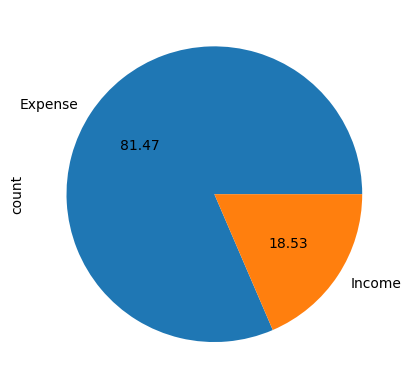

In [10]:
df['Type'].value_counts().plot(kind='pie', autopct='%.2f')

### EDA on DATEs

In [11]:
# step1: conversion
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     1500 non-null   datetime64[ns]
 1   Transaction Description  1500 non-null   object        
 2   Category                 1500 non-null   object        
 3   Amount                   1500 non-null   float64       
 4   Type                     1500 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 58.7+ KB


In [13]:
# step2: Basic Checks

# a.
df['Date'].min()

Timestamp('2020-01-02 00:00:00')

In [14]:
df['Date'].max()

Timestamp('2024-12-29 00:00:00')

This consists of finance data over the 5 years!

<Axes: ylabel='count'>

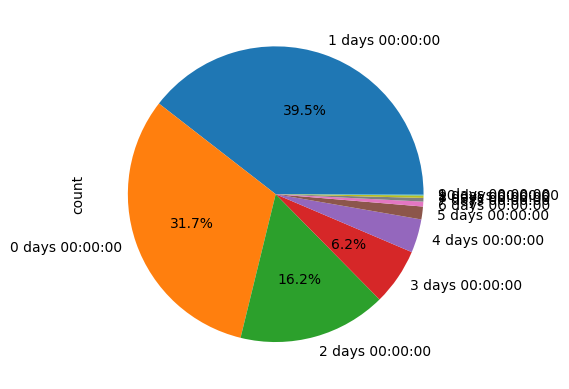

In [15]:
# sol 2: hiding the pct

def autopct_func(pct):
    return f'{pct:.1f}%' if pct > 5 else ''

df['Date'].diff(periods=1).value_counts().plot(kind='pie', autopct=autopct_func, startangle=0) # gaps

In [16]:
values = df['Date'].diff(periods=1).value_counts().tolist()
values

[592, 475, 243, 93, 55, 21, 8, 6, 4, 1, 1]

In [17]:
threshold = 100
explode = [0 if v > threshold else 0.3 for v in values]

<Axes: ylabel='count'>

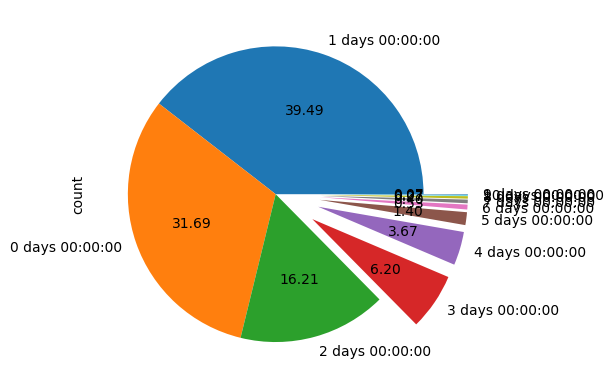

In [18]:
df['Date'].diff(periods=1).value_counts().plot(kind='pie', autopct='%.2f', explode=explode)

In [19]:
# explode didn't help much, moving to solution 2
vc = df['Date'].diff().value_counts()
threshold = 55

major_labels = vc[vc>=threshold]
others_sum = vc[vc<threshold].sum()
print(others_sum)

if others_sum > 0:
    major_labels['More than 4'] = others_sum
    
print(major_labels)

41
Date
1 days 00:00:00    592
0 days 00:00:00    475
2 days 00:00:00    243
3 days 00:00:00     93
4 days 00:00:00     55
More than 4         41
Name: count, dtype: int64


<Axes: ylabel='Expenditure Date'>

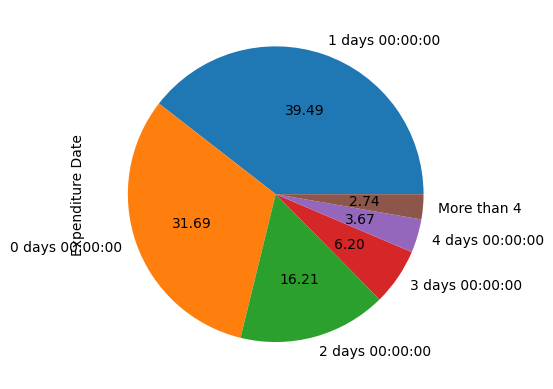

In [20]:
major_labels.name = 'Expenditure Date' # to override default name "count"
major_labels.plot(kind='pie', autopct='%.2f')

In [21]:
# step3: missing dates

date_range = pd.date_range(df['Date'].min(), df['Date'].max())
date_range # SHOULD EXIST

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-04', '2020-01-05',
               '2020-01-06', '2020-01-07', '2020-01-08', '2020-01-09',
               '2020-01-10', '2020-01-11',
               ...
               '2024-12-20', '2024-12-21', '2024-12-22', '2024-12-23',
               '2024-12-24', '2024-12-25', '2024-12-26', '2024-12-27',
               '2024-12-28', '2024-12-29'],
              dtype='datetime64[ns]', length=1824, freq='D')

In [22]:
missing = date_range.difference(df['Date']) # difference = SHOULD EXIST − ACTUALLY EXISTS
missing

DatetimeIndex(['2020-01-03', '2020-01-06', '2020-01-07', '2020-01-08',
               '2020-01-09', '2020-01-10', '2020-01-11', '2020-01-12',
               '2020-01-15', '2020-01-16',
               ...
               '2024-12-13', '2024-12-14', '2024-12-17', '2024-12-18',
               '2024-12-20', '2024-12-22', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27'],
              dtype='datetime64[ns]', length=799, freq=None)

In [23]:
# step4: extracting useful features (core of data EDA)

# GROUP ANALYSIS, for time series analysis

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()
df['Week'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter

In [24]:
df.head()

,Date,Transaction Description,Category,Amount,Type,Year,Month,Day,Weekday,Week,Quarter
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense,2020,1,2,Thursday,1,1
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense,2020,1,2,Thursday,1,1
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense,2020,1,4,Saturday,1,1
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income,2020,1,5,Sunday,1,1
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense,2020,1,13,Monday,3,1


<Axes: xlabel='count', ylabel='Weekday'>

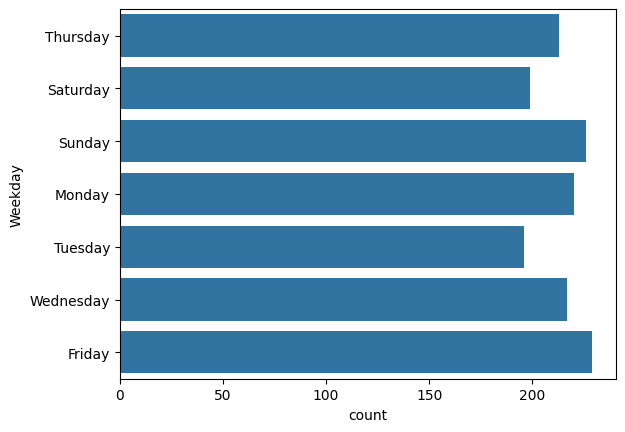

In [25]:
sns.countplot(df['Weekday'])

Text(0.5, 1.0, 'Finance distribution based on Weekdays')

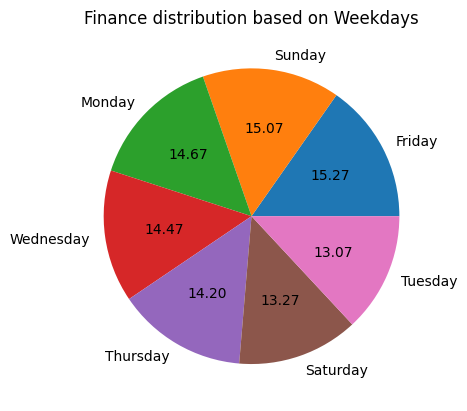

In [26]:
df['Weekday'].value_counts().plot(kind='pie', autopct='%.2f')
plt.ylabel("")
plt.title("Finance distribution based on Weekdays")

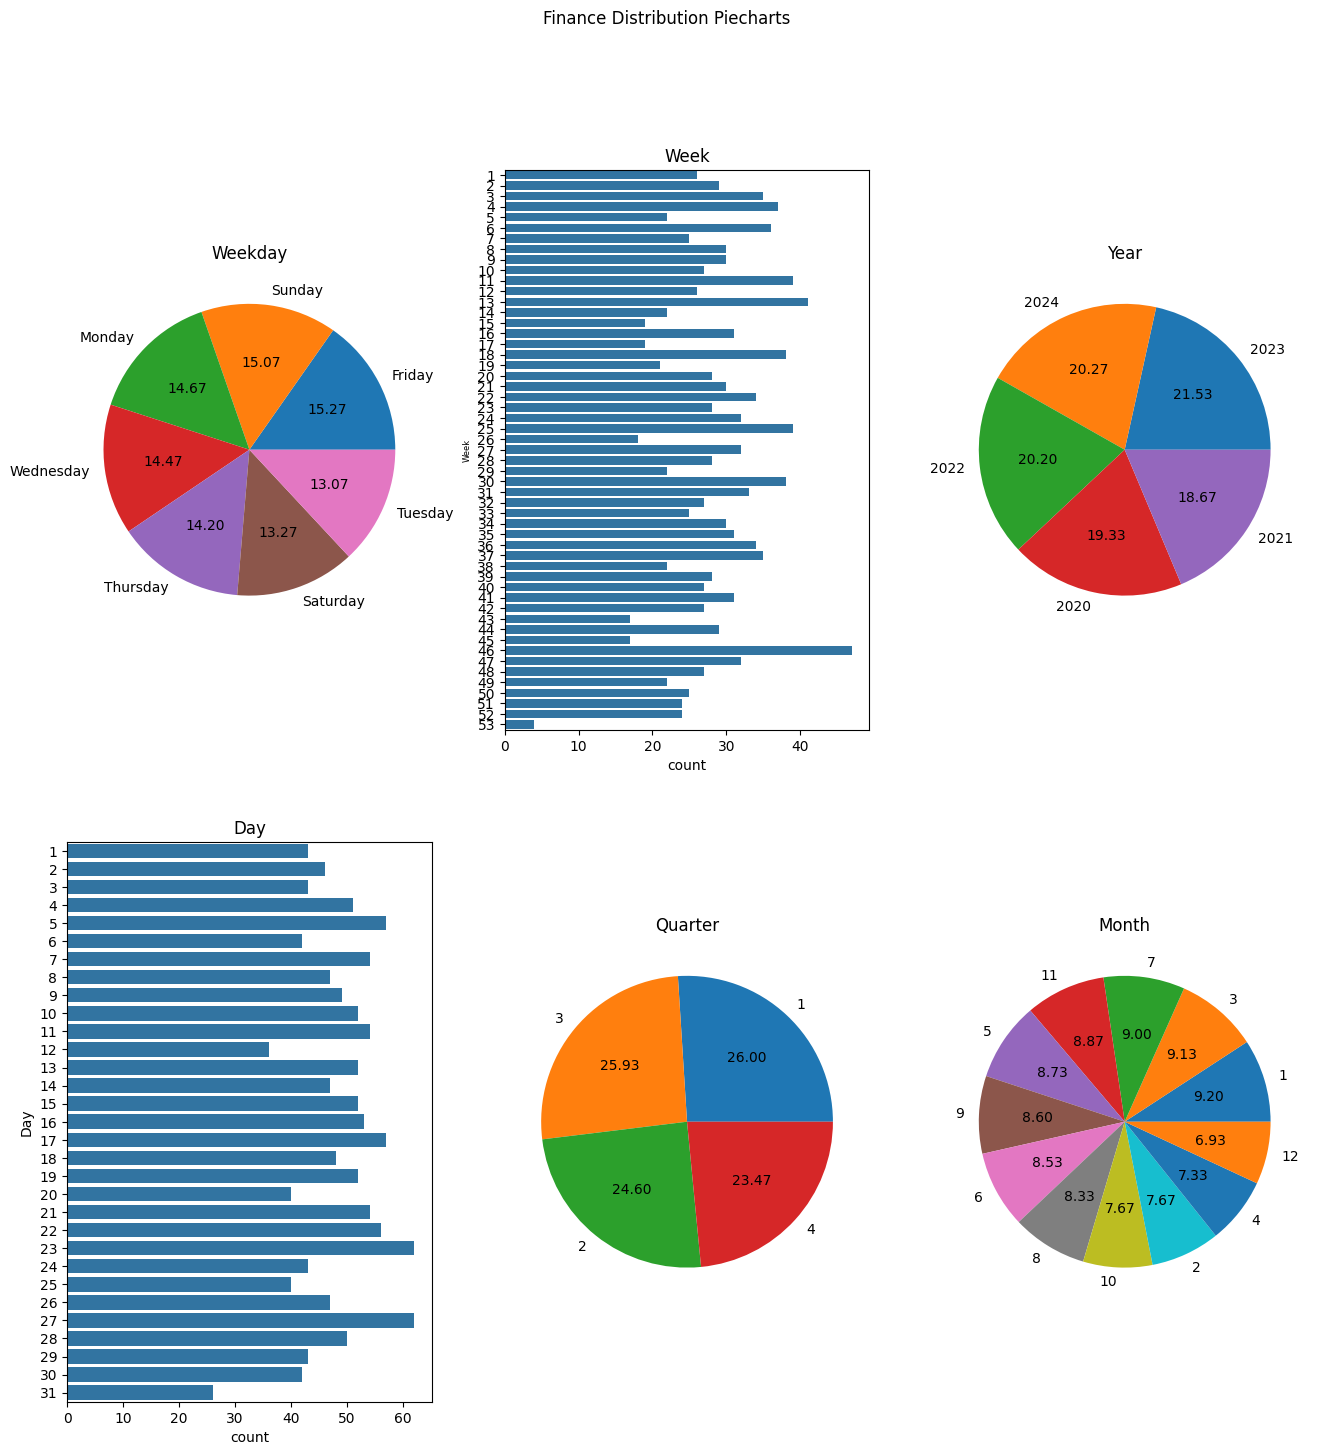

In [50]:
fig, axes = plt.subplots(2,3, figsize=(16,16))
fig.suptitle("Finance Distribution Piecharts")

axes[0,0].pie(df['Weekday'].value_counts(), autopct='%.2f', labels = df['Weekday'].value_counts().index)
axes[0,0].set_title("Weekday")

sns.countplot(df['Week'].astype(str), ax=axes[0,1], order=sorted(df['Week'], key=int))
axes[0,1].set_title("Week")
axes[0,1].set_ylabel("Week", fontsize=6)

axes[0,2].pie(df['Year'].value_counts(), autopct='%.2f', labels = df['Year'].value_counts().index)
axes[0,2].set_title("Year")

sns.countplot(df['Day'].astype(str), ax=axes[1,0], order=sorted(df['Day'], key=int))
axes[1,0].set_title("Day")
axes[1,0].set_ylabel("Day", fontsize=10)

axes[1,1].pie(df['Quarter'].value_counts(), autopct='%.2f', labels = df['Quarter'].value_counts().index)
axes[1,1].set_title("Quarter")

axes[1,2].pie(df['Month'].value_counts(), autopct='%.2f', labels = df['Month'].value_counts().index)
axes[1,2].set_title("Month")

plt.show()


In [ ]:
df['Weekday'].value_counts().index

Index(['Friday', 'Sunday', 'Monday', 'Wednesday', 'Thursday', 'Saturday',
       'Tuesday'],
      dtype='object', name='Weekday')

In [51]:
df.groupby("Year").size()

Year
2020    290
2021    280
2022    303
2023    323
2024    304
dtype: int64

In [52]:
df.groupby("Month").size()

Month
1     138
2     115
3     137
4     110
5     131
6     128
7     135
8     125
9     129
10    115
11    133
12    104
dtype: int64

In [53]:
df.groupby("Weekday").size()

Weekday
Friday       229
Monday       220
Saturday     199
Sunday       226
Thursday     213
Tuesday      196
Wednesday    217
dtype: int64

In [54]:
df.groupby(['Year', 'Month']).size()

Year  Month
2020  1        17
      2        22
      3        17
      4        17
      5        24
      6        27
      7        25
      8        31
      9        25
      10       29
      11       29
      12       27
2021  1        25
      2        19
      3        35
      4        25
      5        29
      6        24
      7        23
      8        21
      9        22
      10       15
      11       20
      12       22
2022  1        22
      2        24
      3        31
      4        25
      5        33
      6        27
      7        26
      8        28
      9        30
      10       21
      11       21
      12       15
2023  1        40
      2        23
      3        33
      4        19
      5        28
      6        26
      7        31
      8        22
      9        26
      10       24
      11       29
      12       22
2024  1        34
      2        27
      3        21
      4        24
      5        17
      6        24
      7        3

In [ ]:
df.groupby('Month')['Day'].mean() # monthly pattern

Month
1     17.217391
2     15.104348
3     16.218978
4     14.790909
5     16.343511
6     15.085938
7     16.777778
8     16.120000
9     14.697674
10    14.930435
11    16.255639
12    16.086538
Name: Day, dtype: float64

In [ ]:
df.groupby("Weekday")['Day'].mean() # weekly pattern

Weekday
Friday       16.288210
Monday       16.454545
Saturday     14.613065
Sunday       16.172566
Thursday     15.521127
Tuesday      16.071429
Wednesday    15.635945
Name: Day, dtype: float64